# Kuramoto exploration

In [1]:
import infotopo_no_prints
import xgi
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import Bunch
from scipy.integrate import solve_ivp

In [2]:
# Normalize the first two columns individually for a given dataframe (range 0-1)
def normalize_columns(df):
    # Normalize first column (index 0)
    min_x, max_x = df.iloc[:, 0].min(), df.iloc[:, 0].max()
    df.iloc[:, 0] = (df.iloc[:, 0] - min_x) / (max_x - min_x) if max_x != min_x else 0
    
    # Normalize second column (index 1)
    min_y, max_y = df.iloc[:, 1].min(), df.iloc[:, 1].max()
    df.iloc[:, 1] = (df.iloc[:, 1] - min_y) / (max_y - min_y) if max_y != min_y else 0
    
    return df

# Optimized function to compute TSE complexity
def compute_tse_complexity(TC_dict):
    """
    Computes the TSE complexity given a dictionary of total correlations.
    
    Parameters:
        TC_dict (dict): Dictionary of total correlations where keys are tuples (subsets).
        
    Returns:
        float: The TSE complexity.
    """
    N = max(len(subset) for subset in TC_dict)  # Maximum subset size
    TSE = 0
    for gamma in range(1, N):
        TC_full = (gamma / N) * TC_dict[tuple(range(1, N + 1))]
        E_TC_gamma = np.mean([TC_dict[subset] for subset in TC_dict if len(subset) == gamma])
        TSE += TC_full - E_TC_gamma
    return TSE

# Convert pandas dataframe to bunch object
def dataframe_to_bunch(dataframe, target=None, feature_names=None, target_names=None, descr="Custom dataset"):
    if feature_names is None:
        feature_names = dataframe.columns.tolist()
    
    return Bunch(
        data=dataframe.to_numpy(),
        target=target if target is not None else np.zeros(dataframe.shape[0]),
        feature_names=feature_names,
        target_names=target_names if target_names is not None else ["target"],
        DESCR=descr
    )

# Obtain topological information metrics using infotopo
def obtain_infotopo_metrics(dataset, dimension_max=0, dimension_tot=0):

    if dimension_max == 0:
        dimension_max = 3 #dataset.shape[1]
    if dimension_tot == 0:
        dimension_tot = 9 #dataset.shape[1]
    
    sample_size = dataset.shape[0]
    nb_of_values = 16
    forward_computation_mode = True
    work_on_transpose = False
    supervised_mode = False
    sampling_mode = 1
    deformed_probability_mode = False

    information_topo = infotopo_no_prints.infotopo(dimension_max = dimension_max,
                                dimension_tot = dimension_tot,
                                sample_size = sample_size,
                                work_on_transpose = work_on_transpose,
                                nb_of_values = nb_of_values,
                                sampling_mode = sampling_mode,
                                deformed_probability_mode = deformed_probability_mode,
                                supervised_mode = supervised_mode,
                                forward_computation_mode = forward_computation_mode)
    
    Nentropie = information_topo.simplicial_entropies_decomposition(dataset)
    Ninfomut = information_topo.simplicial_infomut_decomposition(Nentropie)
    Nfree_energy = information_topo.total_correlation_simplicial_lanscape(Nentropie)
    
    return  Nentropie, Ninfomut, Nfree_energy

# Function to compute metrics for a time window sliding over a given timeseries
def interactions_values_relative(df_input, window_size=0, window_step=0, dimension_max=0, dimension_tot=0):
    # Initialize an empty DataFrame
    columns = ['R_sum', 'S_sum', 'TSE_value', 'R_std', 'S_std', 'TC_lists']
    df_output = pd.DataFrame(columns=columns)

    # Set initial window conditions
    if window_size == 0:
        window_size = len(df_input)-1
    if window_step == 0:
        window_step = 1
    window_start = 0
    window_end = window_start + window_size

    while window_end < len(df_input):
        bunch_data = dataframe_to_bunch(df_input.iloc[window_start:window_end])
        Nentropie, Ninfomut, Nfree_energy = obtain_infotopo_metrics(bunch_data.data, dimension_max, dimension_tot)

        S_values = [(TC - MI) / 2 for TC, MI in zip(Nfree_energy.values(), Ninfomut.values())]
        R_values = [(TC + MI) / 2 for TC, MI in zip(Nfree_energy.values(), Ninfomut.values())]
        S_std = np.std(S_values, ddof=1)
        R_std = np.std(R_values, ddof=1)
        S_sum = sum(S_values)
        R_sum = sum(R_values)
        TSE_value = compute_tse_complexity(Nfree_energy)

        # Add the new values to the dataframe
        new_row = pd.DataFrame({'R_sum': [R_sum], 'S_sum': [S_sum], 'TSE_value': [TSE_value], 'R_std': [R_std], 'S_std':[S_std], 'TC_lists':[Ninfomut]})
        df_output = pd.concat([df_output, new_row], ignore_index=True)
        
        window_start += window_step
        window_end += window_step

    # Normalize all the values so that the S and R values are all positive and the maximum R and S are 1 and minimum 0.
    min_R = df_output.iloc[:, 0].min()
    df_output.iloc[:, 0] += abs(min_R)

    df_output['S_sum'] = (df_output['S_sum'] - df_output['S_sum'].min()) / (df_output['S_sum'].max() - df_output['S_sum'].min())
    df_output['R_sum'] = (df_output['R_sum'] - df_output['R_sum'].min()) / (df_output['R_sum'].max() - df_output['R_sum'].min())

    return df_output

# Simulate Kuramoto model for high order interactions with XGI
def simulate_kuramoto_xgi(H, K2, K3, T=20, dt=0.01):
    timesteps = int(T / dt)
    H_int = xgi.convert_labels_to_integers(H, "label")
    
    links = H_int.edges.filterby("size", 2).members()
    triangles = H_int.edges.filterby("size", 3).members()
    n = H_int.num_nodes

    theta_time = np.zeros((timesteps, n))
    times = np.arange(timesteps) * dt

    omega = np.random.normal(0, 1, n)
    theta = np.random.random(n) * 2 * np.pi

    # Create adjacency structures
    A2 = np.zeros((n, n))
    for i, j in links:
        A2[i, j] = 1
        A2[j, i] = 1

    A3 = np.zeros((n, n, n))
    for i, j, k in triangles:
        A3[i, j, k] = 1
        A3[i, k, j] = 1
        A3[j, i, k] = 1
        A3[j, k, i] = 1
        A3[k, i, j] = 1
        A3[k, j, i] = 1

    for t in range(timesteps):
        theta_time[t] = theta
        d_theta = np.zeros(n)

        for i in range(n):
            # Pairwise interaction
            for j in range(n):
                if A2[i, j]:
                    d_theta[i] += K2 * np.sin(theta[j] - theta[i])

            # Triadic interaction
            for j in range(n):
                for k in range(n):
                    if A3[i, j, k]:
                        d_theta[i] += K3 * np.sin(theta[j] + theta[k] - 2 * theta[i])

        theta += (omega + d_theta) * dt

    frequencies_df = pd.DataFrame(theta_time, index=times)
    return frequencies_df, theta_time

In [4]:
# Compute order parameter from theta time series
def compute_order_parameter(theta_time):
    return np.abs(np.mean(np.exp(1j * theta_time), axis=1))

# Main simulation sweep
N = 8
T = 10
dt = 0.01
max_dim = 3
K_vals = np.linspace(0, 10, 100)
avg_r_vals = []

# Initialize empty hypergraph
H = xgi.Hypergraph()
H.add_nodes_from(range(N))

# Add all possible edges of size 2 to max_dim (inclusive)
for k in range(2, max_dim + 1):
    for edge in itertools.combinations(range(N), k):
        H.add_edge(edge)

# Loop through K values
for K in K_vals:
    K2 = K / N
    K3 = K / N
    theta_time = simulate_kuramoto_xgi(H, K2, K3, T, dt)[1]
    r_t = compute_order_parameter(theta_time)
    avg_r = np.mean(r_t[int(0.5 * len(r_t)):])  # exclude transient
    avg_r_vals.append(avg_r)

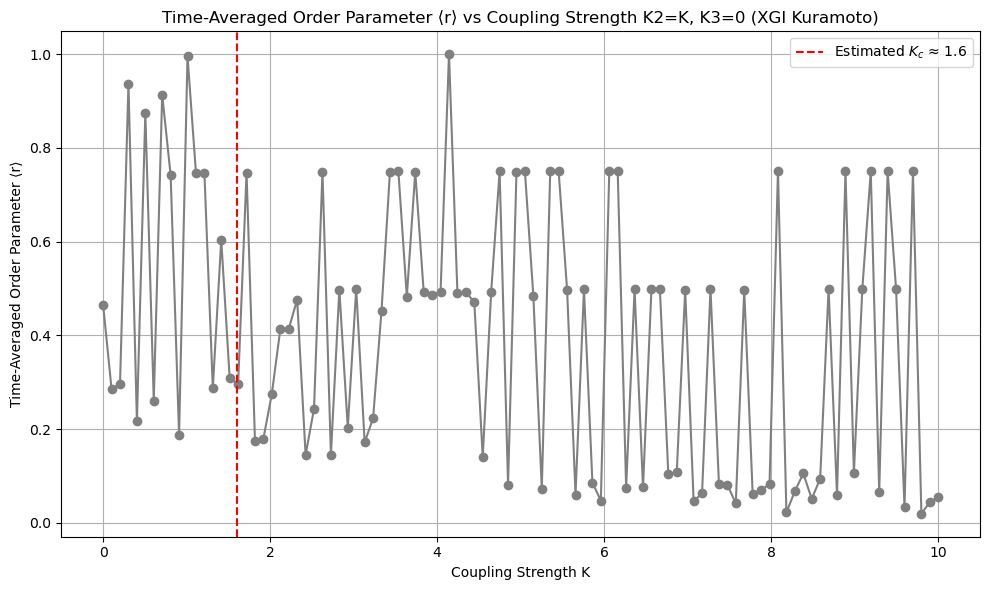

In [5]:
# Fit a smooth average line using a polynomial (e.g., degree 3)
coeffs = np.polyfit(K_vals, avg_r_vals, deg=3)
poly_fit = np.poly1d(coeffs)
smooth_r_vals = poly_fit(K_vals)

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(K_vals, avg_r_vals, marker='o', color='gray', alpha=1)
# plt.plot(K_vals, smooth_r_vals, color='red', linewidth=2)
plt.axvline(x=1.6, linestyle='--', color='red', label='Estimated $K_c$ ≈ 1.6')
plt.title("Time-Averaged Order Parameter ⟨r⟩ vs Coupling Strength K2=K, K3=0 (XGI Kuramoto)")
plt.xlabel("Coupling Strength K")
plt.ylabel("Time-Averaged Order Parameter ⟨r⟩")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Parameters
N = 10   # Number of oscillators
K = 3.0  # Coupling strength
T = 10   # Total time
dt = 0.01  # Time step
K2 = K/N # Pairwise coupling
K3 = K/N  # Triplet coupling
n_simulations = 1
max_dim = 3 # dimension max of hypergraph

# Initialize empty hypergraph
H = xgi.Hypergraph()
H.add_nodes_from(range(N))

# Add all possible edges of size 2 to max_dim (inclusive)
for k in range(2, max_dim + 1):
    for edge in itertools.combinations(range(N), k):
        H.add_edge(edge)

# Run n simulations of the same settings
for n in range(n_simulations):
    # Run the simulation
    frequencies_df = simulate_xgi_time_series(N, K, T=10, dt=0.01, n_sim=4)[2]
    # frequencies_df = simulate_kuramoto_xgi(H, K2, K3, T, dt)[0]
    # frequencies_df = simulate_kuramoto(N, K2, T, dt)

    # Obtain information metrics
    window_size = 400
    window_step = 6
    dimension_max = 6
    dimension_tot = 6

    df_oscillators = interactions_values_relative(frequencies_df[0], window_size, window_step, dimension_max, dimension_tot)

         osc_0     osc_1     osc_2     osc_3     osc_4     osc_5     osc_6  \
0.00 -2.116250  4.173845 -0.248227 -0.613629  0.955662  0.785922  0.236313   
0.01 -2.116420  4.205532 -0.252798 -0.609484  0.944709  0.789213  0.226012   
0.02 -2.116767  4.268896 -0.261839 -0.601168  0.922772  0.795815  0.205254   
0.03 -2.117087  4.332102 -0.270655 -0.592826  0.900797  0.802462  0.184197   
0.04 -2.117302  4.394879 -0.279200 -0.584511  0.878831  0.809155  0.162861   
...        ...       ...       ...       ...       ...       ...       ...   
9.95 -0.099615  1.780559 -0.051305 -0.055268  0.013734 -0.043075  0.065608   
9.96 -0.103846  1.814078 -0.055360 -0.059348  0.010368 -0.047070  0.063110   
9.97 -0.108212  1.848865 -0.059562 -0.063575  0.006859 -0.051214  0.060485   
9.98 -0.112715  1.884960 -0.063917 -0.067954  0.003200 -0.055511  0.057728   
9.99 -0.115002  1.903340 -0.066132 -0.070182  0.001333 -0.057698  0.056316   

         osc_7     osc_8     osc_9  
0.00 -0.363296 -1.212795 -

C:\Users\cyril\AppData\Local\Temp\ipykernel_1103436\4244842013.py:105: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output = pd.concat([df_output, new_row], ignore_index=True)


In [ ]:
frequencies_df = pd.read_csv('Data\Kuramoto_data\XGI\kuramoto_frequencies_timeseries_N10_K3.0_T10_2.csv')
frequencies_df.head()

# Obtain information metrics
window_size = 400
window_step = 6
dimension_max = 6
dimension_tot = 6

df_oscillators = interactions_values_relative(frequencies_df, window_size, window_step, dimension_max, dimension_tot)

<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\cyril\AppData\Local\Temp\ipykernel_1103436\4235669493.py:1: SyntaxWarning: invalid escape sequence '\K'
  frequencies_df = pd.read_csv('Data\Kuramoto_data\XGI\kuramoto_frequencies_timeseries_N10_K3.0_T10_2.csv')
C:\Users\cyril\AppData\Local\Temp\ipykernel_1103436\4244842013.py:105: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output = pd.concat([df_output, new_row], ignore_index=True)


In [45]:
df_oscillators

,R_sum,S_sum,TSE_value,R_std,S_std,TC_lists
0,0.707399,0.439671,7.403781,1.111417,1.620686,"{(1,): 1.9977204109135245, (2,): 3.48739678462..."
1,0.707120,0.432292,7.287592,1.109140,1.605785,"{(1,): 1.9075788589271265, (2,): 3.44769452183..."
2,0.661455,0.392617,7.076394,1.088764,1.556315,"{(1,): 1.8417414409324553, (2,): 3.40125699880..."
3,0.626755,0.369983,6.905306,1.069546,1.526395,"{(1,): 1.7881676636799215, (2,): 3.34704706252..."
4,0.611903,0.355511,6.767830,1.063012,1.503992,"{(1,): 1.7345903350701986, (2,): 3.29016462108..."
...,...,...,...,...,...,...
95,0.961178,0.983012,10.892408,1.313600,2.301679,"{(1,): 3.2474910183062713, (2,): 3.55343342721..."
96,0.923375,0.983977,10.880143,1.303910,2.301856,"{(1,): 3.2618036058838347, (2,): 3.53820526015..."
97,0.950791,0.978276,10.849634,1.309550,2.294883,"{(1,): 3.3064783735627903, (2,): 3.48080266606..."
98,0.962106,0.952795,10.747004,1.317037,2.265384,"{(1,): 3.2532307736899573, (2,): 3.47583529367..."


In [46]:
data = df_oscillators["TC_lists"][0]
# data = ast.literal_eval(data)

# Count occurrences of each key length
length_counts = {}

for key in data.keys():
    length = len(key)  # Get length of the tuple (key)
    length_counts[length] = length_counts.get(length, 0) + 1

# Initialize variables
cumulative_sum = 0
orders_list = []

# Iterate through dictionary values and compute cumulative sums
for value in length_counts.values():
    cumulative_sum += value  # Add current value to the cumulative sum
    orders_list.append(cumulative_sum)  # Store the cumulative sum

# Convert keys to strings and store in a list
keys_list = [str(key) for key in length_counts.keys()]

C:\Users\cyril\AppData\Local\Temp\ipykernel_1103436\1877430228.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


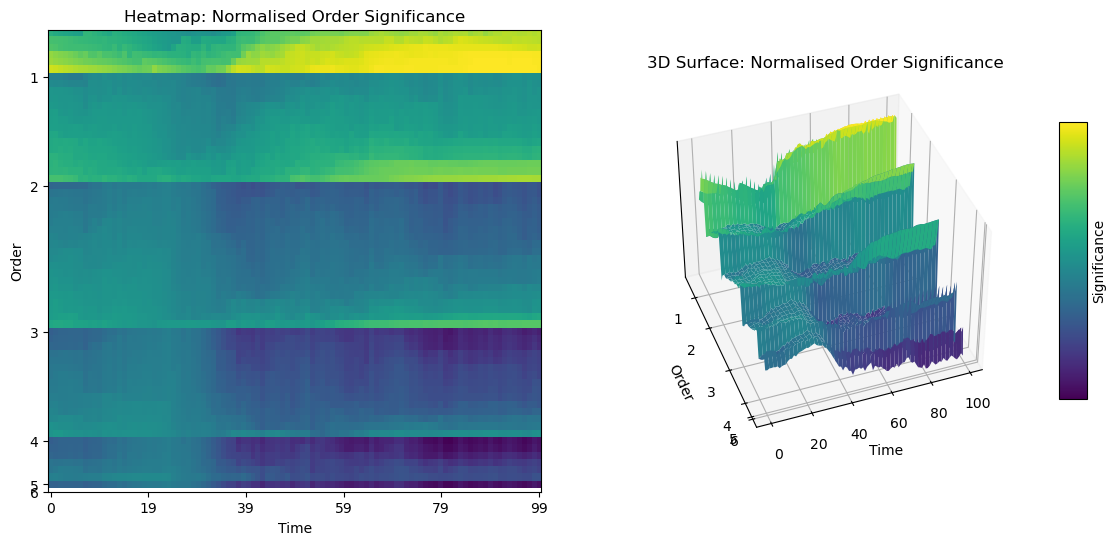

In [47]:
# Define data directly as a list of lists
data = []

for TC_dictionary in df_oscillators['TC_lists']:
    # TC_dictionary = ast.literal_eval(TC_dictionary)
    sorted_dict = dict(sorted(TC_dictionary.items(), key=lambda item: (len(item[0]), item[1])))
    data.append(list(sorted_dict.values()))

# Convert to NumPy array
data = np.array(data)

# Keep only the first part
data = data[:]

# Define time and order indices
x = np.arange(data.shape[0])  # Time steps
y = np.arange(data.shape[1])  # Order indices
X, Y = np.meshgrid(x, y, indexing="xy")  # Corrected meshgrid orientation
Z = data.T  # Transpose to align with heatmap orientation

# Create figure with two subplots (side-by-side)
fig = plt.figure(figsize=(14, 6))

### First Plot (Heatmap) ###
ax1 = fig.add_subplot(1, 2, 1)  # First subplot

cax = ax1.imshow(data.T, aspect='auto', cmap='viridis', origin='lower')

# Remove colorbar for first plot
# cbar1 = fig.colorbar(cax, ax=ax1, label="Significance")  # <- This line is removed

# Set x-axis (time)
ax1.set_xlabel("Time")
ax1.set_xticks(np.linspace(0, data.shape[0] - 1, 6))
ax1.set_xticklabels(np.linspace(0, data.shape[0] - 1, 6, dtype=int))

# Set y-axis (order)
ax1.set_ylabel("Order")
ax1.set_yticks(orders_list)
ax1.set_yticklabels(keys_list)
ax1.set_title("Heatmap: Normalised Order Significance")

ax1.invert_yaxis()  # Invert y-axis direction

### Second Plot (3D Surface) ###
ax2 = fig.add_subplot(1, 2, 2, projection='3d')  # Second subplot

# Set the view angle
ax2.view_init(elev=40, azim=-110)

# Create surface plot
surf = ax2.plot_surface(X, Y, Z, cmap='viridis')

# Add colorbar only to the second plot
cbar2 = fig.colorbar(surf, ax=ax2, shrink=0.6, aspect=10, pad=0.1, label="Significance")

# Remove numbers from the colorbar
cbar2.set_ticks([])  # This removes the tick marks
cbar2.ax.set_yticklabels([])  # This removes the tick labels

# Set y-axis ticks and labels
ax2.set_yticks(orders_list)
ax2.set_yticklabels(keys_list)
ax2.invert_yaxis()  # **Ensure y-axis matches heatmap**

# Labels
ax2.set_xlabel("Time")
ax2.set_ylabel("Order")
ax2.set_zticks([])  # Remove z-axis ticks
ax2.set_title("3D Surface: Normalised Order Significance")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Compare HOI vs Baudot metric

In [128]:
import infotopo_no_prints
import xgi
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import Bunch
from scipy.integrate import solve_ivp

In [129]:
# === XGI Kuramoto ===
def kuramoto_xgi(t, theta, omega, K2, K3, H, N):
    H_int = xgi.convert_labels_to_integers(H, "label")
    links = H_int.edges.filterby("size", 2).members()
    triangles = H_int.edges.filterby("size", 3).members()
    dtheta = np.zeros(N)
    r1 = np.zeros(N, dtype=complex)
    r2 = np.zeros(N, dtype=complex)
    for i, j in links:
        r1[i] += np.exp(1j * theta[j])
        r1[j] += np.exp(1j * theta[i])
    for i, j, k in triangles:
        r2[i] += np.exp(2j * theta[j] - 1j * theta[k]) + np.exp(2j * theta[k] - 1j * theta[j])
        r2[j] += np.exp(2j * theta[i] - 1j * theta[k]) + np.exp(2j * theta[k] - 1j * theta[i])
        r2[k] += np.exp(2j * theta[i] - 1j * theta[j]) + np.exp(2j * theta[j] - 1j * theta[i])
    for i in range(N):
        dtheta[i] = omega[i] + K2 * np.imag(r1[i] * np.exp(-1j * theta[i])) + K3 * np.imag(r2[i] * np.exp(-1j * theta[i]))
    return dtheta

def simulate_xgi_time_series(N, K, T=10, dt=0.01, n_sim=4):
    # generate fully connected hypergraph of N nodes
    H = xgi.Hypergraph()
    nodes = list(range(N))
    H.add_nodes_from(nodes)
    max_order = 3
    
    for k in range(1, max_order + 1):
        for edge in itertools.combinations(nodes, k):
            H.add_edge(edge)
    
    t_eval = np.arange(0, T, dt)
    K2 = K / N
    K3 = K / N  # Adjust if high order included

    r_all = []
    freq_dfs = []

    for _ in range(n_sim):
        omega = np.random.normal(0, 1, N)
        theta0 = np.random.uniform(0, 2*np.pi, N)

        sol = solve_ivp(kuramoto_xgi, [0, T], theta0, t_eval=t_eval, args=(omega, K2, K3, H, N))
        theta_ts = sol.y.T

        # Instantaneous frequencies
        freqs = np.gradient(theta_ts, axis=0) / dt
        freq_df = pd.DataFrame(freqs, index=t_eval, columns=[f"osc_{i}" for i in range(N)])
        freq_dfs.append(freq_df)

        # Order parameter
        r = np.abs(np.mean(np.exp(1j * theta_ts), axis=1))
        r_all.append(r)

    r_all = np.array(r_all)
    return t_eval, r_all, freq_dfs

def simulate_xgi_r_vs_K(N, K_vals, T=20, dt=0.01, n_sim=4):
    all_r = []

    for sim in range(n_sim):
        r_per_sim = []
        for K in K_vals:
            H = xgi.Hypergraph()
            H.add_nodes_from(range(N))
            for i in range(N):
                for j in range(i + 1, N):
                    H.add_edge([i, j])

            K2 = K / N
            K3 = 0
            omega = np.random.normal(0, 1, N)
            theta = np.random.uniform(0, 2*np.pi, N)
            timesteps = int(T / dt)
            theta_time = np.zeros((timesteps, N))
            theta_curr = theta.copy()
            links = H.edges.filterby("size", 2).members()
            triangles = H.edges.filterby("size", 3).members()

            for t in range(timesteps):
                theta_time[t] = theta_curr
                r1 = np.zeros(N, dtype=complex)
                r2 = np.zeros(N, dtype=complex)
                for i, j in links:
                    r1[i] += np.exp(1j * theta_curr[j])
                    r1[j] += np.exp(1j * theta_curr[i])
                for i, j, k in triangles:
                    r2[i] += np.exp(2j * theta_curr[j] - 1j * theta_curr[k]) + np.exp(2j * theta_curr[k] - 1j * theta_curr[j])
                    r2[j] += np.exp(2j * theta_curr[i] - 1j * theta_curr[k]) + np.exp(2j * theta_curr[k] - 1j * theta_curr[i])
                    r2[k] += np.exp(2j * theta_curr[i] - 1j * theta_curr[j]) + np.exp(2j * theta_curr[j] - 1j * theta_curr[i])
                dtheta = omega + K2 * np.imag(r1 * np.exp(-1j * theta_curr)) + K3 * np.imag(r2 * np.exp(-1j * theta_curr))
                theta_curr += dtheta * dt

            r = np.abs(np.mean(np.exp(1j * theta_time), axis=1))
            r_per_sim.append(np.mean(r[int(0.5 * len(r)):]))

        all_r.append(r_per_sim)

    all_r = np.array(all_r)
    mean_r = np.mean(all_r, axis=0)
    return all_r, mean_r

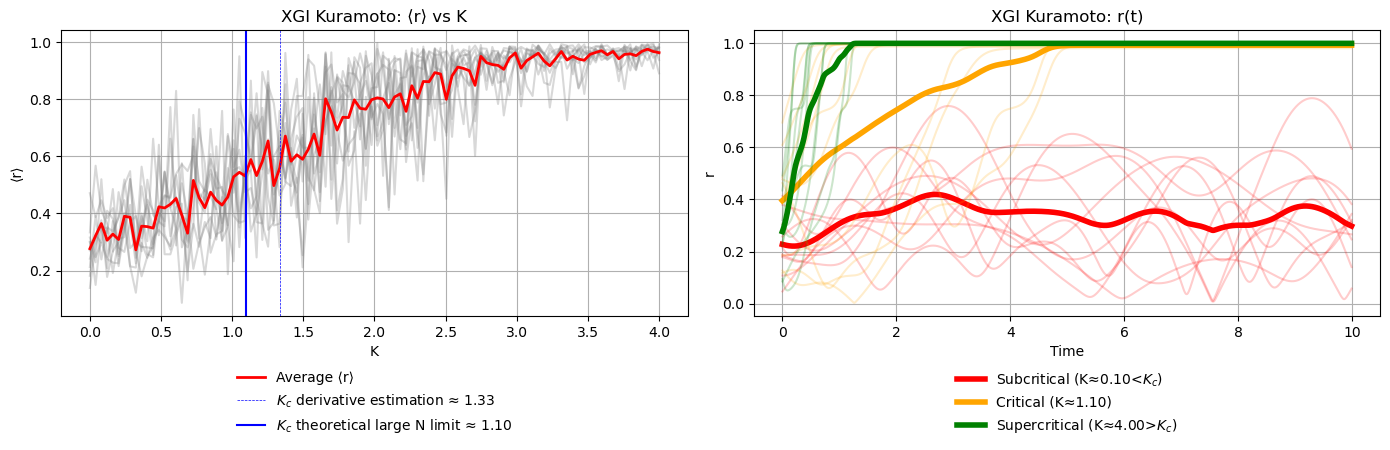

In [132]:
# === Plotting ===
n_simulations = 10
N = 8
T = 10
dt = 0.01
Kc_theoretical = 1.1 #1.5958    # Theoretical estimation of critical coupling in the large N limit
K_vals = np.linspace(0, 4, 100)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # Only 1 row for 2 plots

# XGI: r vs K
all_r_xgi, mean_r_xgi = simulate_xgi_r_vs_K(N, K_vals, T, dt, n_simulations)
r_diff_xgi = np.gradient(mean_r_xgi, K_vals)
Kc_xgi = K_vals[np.argmax(r_diff_xgi)]

# XGI: r vs K plot
for sim_r in all_r_xgi:
    axs[0].plot(K_vals, sim_r, color='gray', alpha=0.3)
axs[0].plot(K_vals, mean_r_xgi, color='red', linewidth=2, label='Average ⟨r⟩')
axs[0].axvline(Kc_xgi, color='blue', linestyle='--', linewidth=0.5, label=f'$K_c$ derivative estimation ≈ {Kc_xgi:.2f}')
axs[0].axvline(Kc_theoretical, color='blue', linestyle='-', label=f'$K_c$ theoretical large N limit ≈ {Kc_theoretical:.2f}')
axs[0].set_title('XGI Kuramoto: ⟨r⟩ vs K')
axs[0].set_xlabel('K')
axs[0].set_ylabel('⟨r⟩')
axs[0].grid(True)
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False)

# XGI: set the conditions for coupling regions
K_sub, K_sup = 0.100, 4.000
Ks_to_plot = [K_sub, Kc_theoretical, K_sup]
colors = ['r', 'orange', 'green']
labels = [f'Subcritical (K≈{K_sub:.2f}<$K_c$)', f'Critical (K≈{Kc_theoretical:.2f})', f'Supercritical (K≈{K_sup:.2f}>$K_c$)']

# XGI: Time series
for K, label, color in zip(Ks_to_plot, labels, colors):
    t, r_all, frequencies = simulate_xgi_time_series(N, K, T, dt, n_simulations)
    for run in r_all:
        axs[1].plot(t, run, color=color, alpha=0.2)
    axs[1].plot(t, r_all.mean(axis=0), color=color, linewidth=4, label=label)
axs[1].set_title('XGI Kuramoto: r(t)')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('r')
axs[1].grid(True)
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [117]:
# Parameters
N = 10   # Number of oscillators
K = 1.5  # Coupling strength
T = 10   # Total time
dt = 0.01  # Time step
n_simulations = 1

# Run n simulations of the same settings
for n in range(n_simulations):
    # Run the simulation
    frequencies_df = simulate_xgi_time_series(N, K, T=10, dt=0.01, n_sim=1)[2]

    # Obtain information metrics
    window_size = 400
    window_step = 6
    dimension_max = 6
    dimension_tot = 6

    df_oscillators = interactions_values_relative(frequencies_df[0], window_size, window_step, dimension_max, dimension_tot)

C:\Users\cyril\AppData\Local\Temp\ipykernel_1103436\4244842013.py:105: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output = pd.concat([df_output, new_row], ignore_index=True)


In [118]:
data = df_oscillators["TC_lists"][0]
# data = ast.literal_eval(data)

# Count occurrences of each key length
length_counts = {}

for key in data.keys():
    length = len(key)  # Get length of the tuple (key)
    length_counts[length] = length_counts.get(length, 0) + 1

# Initialize variables
cumulative_sum = 0
orders_list = []

# Iterate through dictionary values and compute cumulative sums
for value in length_counts.values():
    cumulative_sum += value  # Add current value to the cumulative sum
    orders_list.append(cumulative_sum)  # Store the cumulative sum

# Convert keys to strings and store in a list
keys_list = [str(key) for key in length_counts.keys()]

C:\Users\cyril\AppData\Local\Temp\ipykernel_1103436\3390939853.py:74: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


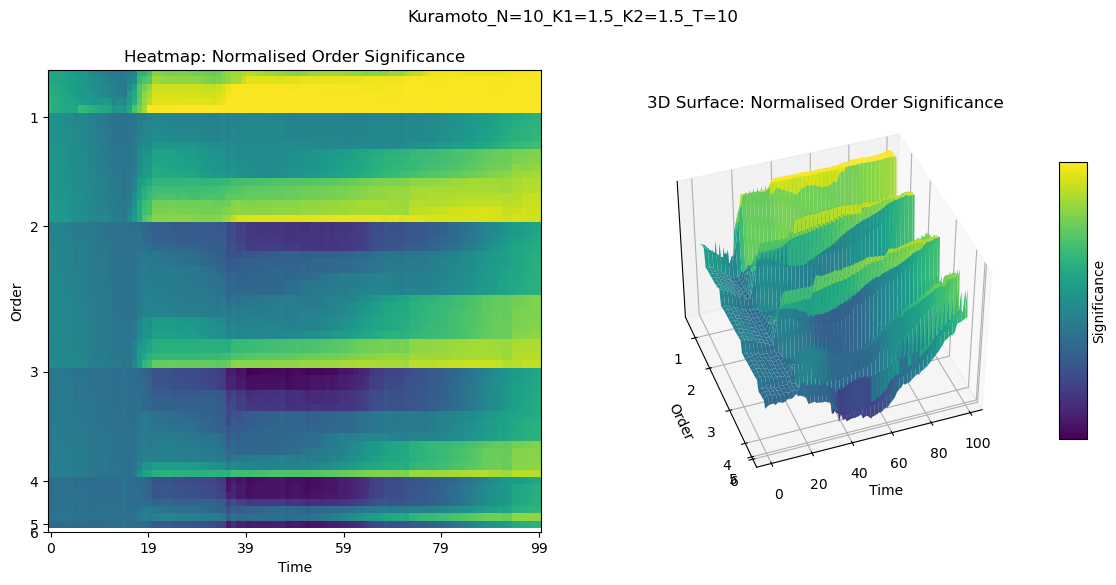

In [119]:
# Define data directly as a list of lists
data = []

for TC_dictionary in df_oscillators['TC_lists']:
    # TC_dictionary = ast.literal_eval(TC_dictionary)
    sorted_dict = dict(sorted(TC_dictionary.items(), key=lambda item: (len(item[0]), item[1])))
    data.append(list(sorted_dict.values()))

# Convert to NumPy array
data = np.array(data)

# Keep only the first part
data = data[:]

# Define time and order indices
x = np.arange(data.shape[0])  # Time steps
y = np.arange(data.shape[1])  # Order indices
X, Y = np.meshgrid(x, y, indexing="xy")  # Corrected meshgrid orientation
Z = data.T  # Transpose to align with heatmap orientation

# Create figure with two subplots (side-by-side)
fig = plt.figure(figsize=(14, 6))

### First Plot (Heatmap) ###
ax1 = fig.add_subplot(1, 2, 1)  # First subplot

cax = ax1.imshow(data.T, aspect='auto', cmap='viridis', origin='lower')

# Remove colorbar for first plot
# cbar1 = fig.colorbar(cax, ax=ax1, label="Significance")  # <- This line is removed

# Set x-axis (time)
ax1.set_xlabel("Time")
ax1.set_xticks(np.linspace(0, data.shape[0] - 1, 6))
ax1.set_xticklabels(np.linspace(0, data.shape[0] - 1, 6, dtype=int))

# Set y-axis (order)
ax1.set_ylabel("Order")
ax1.set_yticks(orders_list)
ax1.set_yticklabels(keys_list)
ax1.set_title("Heatmap: Normalised Order Significance")

ax1.invert_yaxis()  # Invert y-axis direction

### Second Plot (3D Surface) ###
ax2 = fig.add_subplot(1, 2, 2, projection='3d')  # Second subplot

# Set the view angle
ax2.view_init(elev=40, azim=-110)

# Create surface plot
surf = ax2.plot_surface(X, Y, Z, cmap='viridis')

# Add colorbar only to the second plot
cbar2 = fig.colorbar(surf, ax=ax2, shrink=0.6, aspect=10, pad=0.1, label="Significance")

# Remove numbers from the colorbar
cbar2.set_ticks([])  # This removes the tick marks
cbar2.ax.set_yticklabels([])  # This removes the tick labels

# Set y-axis ticks and labels
ax2.set_yticks(orders_list)
ax2.set_yticklabels(keys_list)
ax2.invert_yaxis()  # **Ensure y-axis matches heatmap**

# Labels
ax2.set_xlabel("Time")
ax2.set_ylabel("Order")
ax2.set_zticks([])  # Remove z-axis ticks
ax2.set_title("3D Surface: Normalised Order Significance")

# Adjust layout for better spacing
plt.suptitle(f'Kuramoto_N={N}_K1={K}_K2={K}_T={T}')
plt.tight_layout()

# Define the save directory (use raw string to avoid escaping issues)
save_dir = r"C:\Users\cyril\Documents\Study\PhD\Logbook\2025\Week 36 (23-06)"
os.makedirs(save_dir, exist_ok=True)

# Define filename and full path
filename = f"Kuramoto_N{N}_K1_{K}_K2_{K}_T_{T}.png"
save_path = os.path.join(save_dir, filename)

# Save the figure
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# Improved code

In [133]:
import infotopo_no_prints
import xgi
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import Bunch
from scipy.integrate import solve_ivp

In [134]:
# === XGI Kuramoto ===
def kuramoto_xgi(t, theta, omega, K2, K3, H, N):
    H_int = xgi.convert_labels_to_integers(H, "label")
    links = H_int.edges.filterby("size", 2).members()
    triangles = H_int.edges.filterby("size", 3).members()
    dtheta = np.zeros(N)
    r1 = np.zeros(N, dtype=complex)
    r2 = np.zeros(N, dtype=complex)
    for i, j in links:
        r1[i] += np.exp(1j * theta[j])
        r1[j] += np.exp(1j * theta[i])
    for i, j, k in triangles:
        r2[i] += np.exp(2j * theta[j] - 1j * theta[k]) + np.exp(2j * theta[k] - 1j * theta[j])
        r2[j] += np.exp(2j * theta[i] - 1j * theta[k]) + np.exp(2j * theta[k] - 1j * theta[i])
        r2[k] += np.exp(2j * theta[i] - 1j * theta[j]) + np.exp(2j * theta[j] - 1j * theta[i])
    for i in range(N):
        dtheta[i] = omega[i] + K2 * np.imag(r1[i] * np.exp(-1j * theta[i])) + K3 * np.imag(r2[i] * np.exp(-1j * theta[i]))
    return dtheta

def simulate_xgi_time_series(N, K2, K3, T=10, dt=0.01, n_sim=4):
    # generate fully connected hypergraph of N nodes
    H = xgi.Hypergraph()
    nodes = list(range(N))
    H.add_nodes_from(nodes)
    max_order = 3
    
    for k in range(1, max_order + 1):
        for edge in itertools.combinations(nodes, k):
            H.add_edge(edge)
    
    t_eval = np.arange(0, T, dt)
    r_all = []
    freq_dfs = []

    for _ in range(n_sim):
        omega = np.random.normal(0, 1, N)
        theta0 = np.random.uniform(0, 2*np.pi, N)

        sol = solve_ivp(kuramoto_xgi, [0, T], theta0, t_eval=t_eval, args=(omega, K2, K3, H, N))
        theta_ts = sol.y.T

        # Instantaneous frequencies
        freqs = np.gradient(theta_ts, axis=0) / dt
        freq_df = pd.DataFrame(freqs, index=t_eval, columns=[f"osc_{i}" for i in range(N)])
        freq_dfs.append(freq_df)

        # Order parameter
        r = np.abs(np.mean(np.exp(1j * theta_ts), axis=1))
        r_all.append(r)

    r_all = np.array(r_all)
    return t_eval, r_all, freq_dfs

def simulate_xgi_r_vs_K(N, K_vals, K2, K3, T=20, dt=0.01, n_sim=4):
    all_r = []

    for sim in range(n_sim):
        r_per_sim = []
        for K in K_vals:
            H = xgi.Hypergraph()
            nodes = list(range(N))
            H.add_nodes_from(nodes)
            max_order = 3
            for k in range(1, max_order + 1):
                for edge in itertools.combinations(nodes, k):
                    H.add_edge(edge)
                    
            omega = np.random.normal(0, 1, N)
            theta = np.random.uniform(0, 2*np.pi, N)
            timesteps = int(T / dt)
            theta_time = np.zeros((timesteps, N))
            theta_curr = theta.copy()
            links = H.edges.filterby("size", 2).members()
            triangles = H.edges.filterby("size", 3).members()

            for t in range(timesteps):
                theta_time[t] = theta_curr
                r1 = np.zeros(N, dtype=complex)
                r2 = np.zeros(N, dtype=complex)
                for i, j in links:
                    r1[i] += np.exp(1j * theta_curr[j])
                    r1[j] += np.exp(1j * theta_curr[i])
                for i, j, k in triangles:
                    r2[i] += np.exp(2j * theta_curr[j] - 1j * theta_curr[k]) + np.exp(2j * theta_curr[k] - 1j * theta_curr[j])
                    r2[j] += np.exp(2j * theta_curr[i] - 1j * theta_curr[k]) + np.exp(2j * theta_curr[k] - 1j * theta_curr[i])
                    r2[k] += np.exp(2j * theta_curr[i] - 1j * theta_curr[j]) + np.exp(2j * theta_curr[j] - 1j * theta_curr[i])
                dtheta = omega + K2 * np.imag(r1 * np.exp(-1j * theta_curr)) + K3 * np.imag(r2 * np.exp(-1j * theta_curr))
                theta_curr += dtheta * dt

            r = np.abs(np.mean(np.exp(1j * theta_time), axis=1))
            r_per_sim.append(np.mean(r[int(0.5 * len(r)):]))

        all_r.append(r_per_sim)

    all_r = np.array(all_r)
    mean_r = np.mean(all_r, axis=0)
    return all_r, mean_r

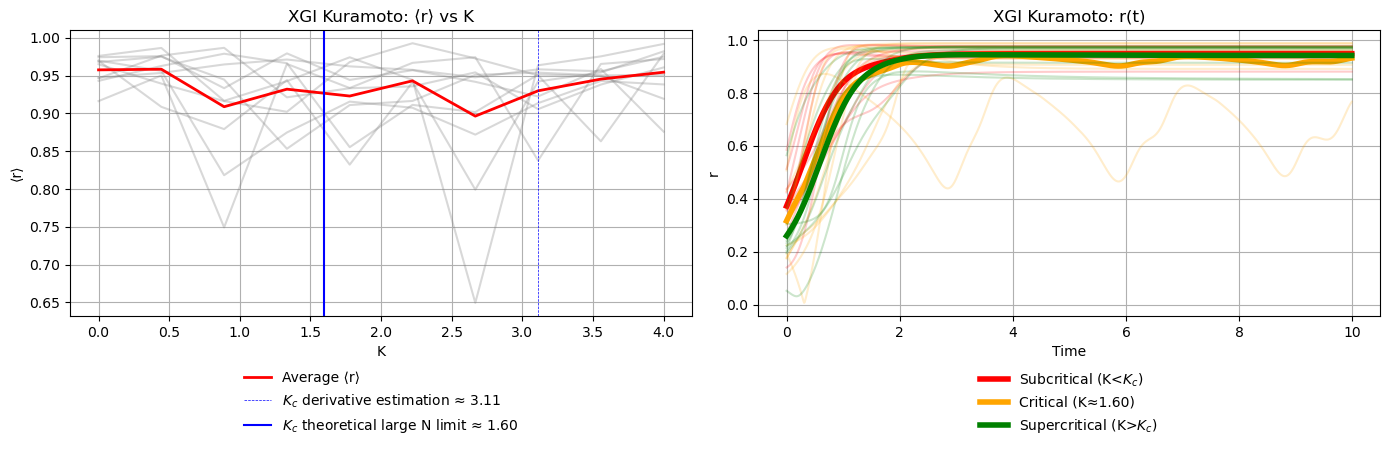

In [135]:
# === Plotting ===
n_simulations = 10
N = 8
T = 10
dt = 0.01
K = 3
K2 = K/N
K3 = 0
Kc_theoretical = 1.5958    # Theoretical estimation of critical coupling in the large N limit
K_vals = np.linspace(0, 4, 10)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # Only 1 row for 2 plots

# XGI: r vs K
all_r_xgi, mean_r_xgi = simulate_xgi_r_vs_K(N, K_vals, K2, K3, T, dt, n_simulations)
r_diff_xgi = np.gradient(mean_r_xgi, K_vals)
Kc_xgi = K_vals[np.argmax(r_diff_xgi)]

# XGI: set the conditions for coupling regions
Ks_to_plot = [Kc_theoretical-1, Kc_theoretical, Kc_theoretical+1]
colors = ['r', 'orange', 'green']
labels = ['Subcritical (K<$K_c$)', f'Critical (K≈{Kc_theoretical:.2f})', 'Supercritical (K>$K_c$)']

# XGI: r vs K plot
for sim_r in all_r_xgi:
    axs[0].plot(K_vals, sim_r, color='gray', alpha=0.3)
axs[0].plot(K_vals, mean_r_xgi, color='red', linewidth=2, label='Average ⟨r⟩')
axs[0].axvline(Kc_xgi, color='blue', linestyle='--', linewidth=0.5, label=f'$K_c$ derivative estimation ≈ {Kc_xgi:.2f}')
axs[0].axvline(Kc_theoretical, color='blue', linestyle='-', label=f'$K_c$ theoretical large N limit ≈ {Kc_theoretical:.2f}')
axs[0].set_title('XGI Kuramoto: ⟨r⟩ vs K')
axs[0].set_xlabel('K')
axs[0].set_ylabel('⟨r⟩')
axs[0].grid(True)
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False)

# XGI: Time series
for K, label, color in zip(Ks_to_plot, labels, colors):
    t, r_all, frequencies = simulate_xgi_time_series(N, K2, K3, T, dt, n_simulations)
    for run in r_all:
        axs[1].plot(t, run, color=color, alpha=0.2)
    axs[1].plot(t, r_all.mean(axis=0), color=color, linewidth=4, label=label)
axs[1].set_title('XGI Kuramoto: r(t)')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('r')
axs[1].grid(True)
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()